# feature engineering 

- #### it is the process of creating new and better feature for our model from which we can have better insight or we can make better prediction

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df=pd.read_csv('Titanic dataset.csv')

In [33]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [34]:
df.shape

(418, 12)

In [35]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [36]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
172,1064,0,3,"Dyker, Mr. Adolf Fredrik",male,23.0,1,0,347072,13.9000,NaN,S
105,997,0,3,"Holthen, Mr. Johan Martin",male,28.0,0,0,C 4001,22.5250,NaN,S
272,1164,1,1,"Clark, Mrs. Walter Miller (Virginia McDowell)",female,26.0,1,0,13508,136.7792,C89,C
124,1016,0,3,"Kennedy, Mr. John",male,NaN,0,0,368783,7.7500,NaN,Q


In [37]:
df['Family Size']=df['SibSp']+df['Parch']+1

In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,2
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,1
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,3


<Axes: xlabel='Family Size', ylabel='Survived'>

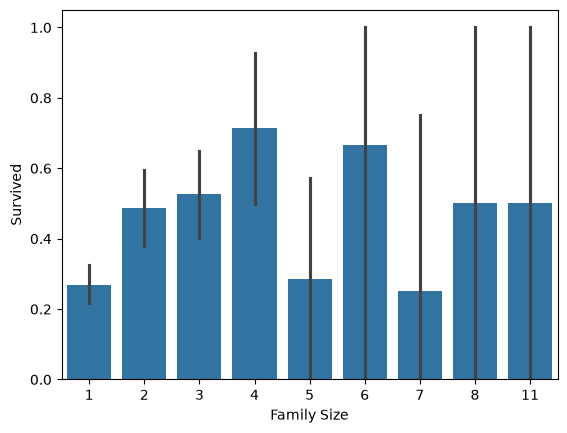

In [39]:
sns.barplot(data=df,x='Family Size',y='Survived')

In [40]:
df['Family Size'].value_counts()

Family Size
1     253
2      74
3      57
4      14
5       7
7       4
11      4
6       3
8       2
Name: count, dtype: int64

# now i want to make a col where ---> 

- ####  if family size is <3 --> small
- ####  if family size is >=3 and <5 --> mediam
- ####  if family size is >=5 ----> large

In [41]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,2
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,1
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,3


In [42]:
df['Family Size'].value_counts()

Family Size
1     253
2      74
3      57
4      14
5       7
7       4
11      4
6       3
8       2
Name: count, dtype: int64

In [43]:
# we will make a function

def fam_type(num):
    if num>=1 and num<3 :
        return 'Small Family'
    elif num>=3 and num<=5:
        return 'Medium Family'
    else:
        return 'Large Family'

In [44]:
df['Family Type']=df['Family Size'].apply(fam_type)

In [45]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Family Type
380,1272,0,3,"O'Connor, Mr. Patrick",male,NaN,0,0,366713,7.7500,NaN,Q,1,Small Family
183,1075,0,3,"Lane, Mr. Patrick",male,NaN,0,0,7935,7.7500,NaN,Q,1,Small Family
407,1299,0,1,"Widener, Mr. George Dunton",male,50.0,1,1,113503,211.5000,C80,C,3,Medium Family
381,1273,0,3,"Foley, Mr. Joseph",male,26.0,0,0,330910,7.8792,NaN,Q,1,Small Family
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S,3,Medium Family


In [46]:
df['Family Type'].value_counts()

Family Type
Small Family     327
Medium Family     78
Large Family      13
Name: count, dtype: int64

In [50]:
x=pd.crosstab(df['Family Type'],df['Survived'],normalize=True)*100

<Axes: xlabel='Survived', ylabel='Family Type'>

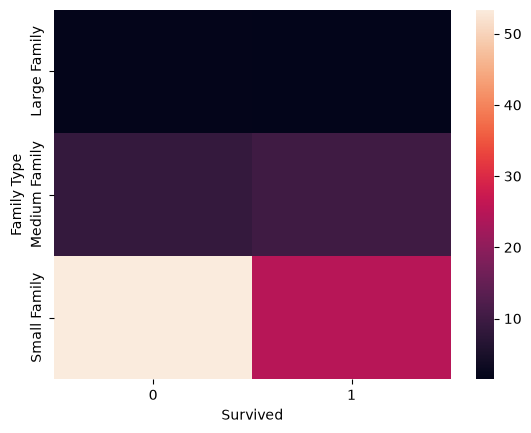

In [52]:
sns.heatmap(x)

In [53]:
df[df['SibSp']==5]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Family Type
140,1032,1,3,"Goodwin, Miss. Jessie Allis",female,10.0,5,2,CA 2144,46.9,NaN,S,8,Large Family


In [54]:
df[df['Ticket']=='CA 2144']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Family Type
139,1031,0,3,"Goodwin, Mr. Charles Frederick",male,40.0,1,6,CA 2144,46.9,NaN,S,8,Large Family
140,1032,1,3,"Goodwin, Miss. Jessie Allis",female,10.0,5,2,CA 2144,46.9,NaN,S,8,Large Family


# what we can see that the fare is mention for the complete family not for a individual person

# if i want to get the fare of invidual member then we have to divid the fare with the faimily member 

In [55]:
df['Individual Fare']=df['Fare']/df['Family Size']

In [56]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Family Type,Individual Fare
55,947,0,3,"Rice, Master. Albert",male,10.0,4,1,382652,29.1250,NaN,Q,6,Large Family,4.854167
219,1111,0,3,"Thomson, Mr. Alexander Morrison",male,NaN,0,0,32302,8.0500,NaN,S,1,Small Family,8.050000
70,962,1,3,"Mulvihill, Miss. Bertha E",female,24.0,0,0,382653,7.7500,NaN,Q,1,Small Family,7.750000
285,1177,0,3,"Dennis, Mr. William",male,36.0,0,0,A/5 21175,7.2500,NaN,S,1,Small Family,7.250000
166,1058,0,1,"Brandeis, Mr. Emil",male,48.0,0,0,PC 17591,50.4958,B10,C,1,Small Family,50.495800


In [58]:
df[df['Ticket']=='CA 2144'][['Fare','Individual Fare','Family Size']]

,Fare,Individual Fare,Family Size
139,46.9,5.8625,8
140,46.9,5.8625,8


------
----

# Abbrivation or prefix of passanger name 

In [59]:
df['Name']

0                                  Kelly, Mr. James
1                  Wilkes, Mrs. James (Ellen Needs)
2                         Myles, Mr. Thomas Francis
3                                  Wirz, Mr. Albert
4      Hirvonen, Mrs. Alexander (Helga E Lindqvist)
                           ...                     
413                              Spector, Mr. Woolf
414                    Oliva y Ocana, Dona. Fermina
415                    Saether, Mr. Simon Sivertsen
416                             Ware, Mr. Frederick
417                        Peter, Master. Michael J
Name: Name, Length: 418, dtype: str

In [70]:
df['Name'].str.split(',')

0                                  [Kelly,  Mr. James]
1                  [Wilkes,  Mrs. James (Ellen Needs)]
2                         [Myles,  Mr. Thomas Francis]
3                                  [Wirz,  Mr. Albert]
4      [Hirvonen,  Mrs. Alexander (Helga E Lindqvist)]
                            ...                       
413                              [Spector,  Mr. Woolf]
414                    [Oliva y Ocana,  Dona. Fermina]
415                    [Saether,  Mr. Simon Sivertsen]
416                             [Ware,  Mr. Frederick]
417                        [Peter,  Master. Michael J]
Name: Name, Length: 418, dtype: object

In [72]:
df['Name'].str.split(',').str[1]

0                                Mr. James
1                 Mrs. James (Ellen Needs)
2                       Mr. Thomas Francis
3                               Mr. Albert
4       Mrs. Alexander (Helga E Lindqvist)
                      ...                 
413                              Mr. Woolf
414                          Dona. Fermina
415                    Mr. Simon Sivertsen
416                          Mr. Frederick
417                      Master. Michael J
Name: Name, Length: 418, dtype: object

In [73]:
df['Name'].str.split(',').str[1].str.split('.')

0                               [ Mr,  James]
1                [ Mrs,  James (Ellen Needs)]
2                      [ Mr,  Thomas Francis]
3                              [ Mr,  Albert]
4      [ Mrs,  Alexander (Helga E Lindqvist)]
                        ...                  
413                             [ Mr,  Woolf]
414                         [ Dona,  Fermina]
415                   [ Mr,  Simon Sivertsen]
416                         [ Mr,  Frederick]
417                     [ Master,  Michael J]
Name: Name, Length: 418, dtype: object

In [74]:
df['Name'].str.split(',').str[1].str.split('.').str[0]

0           Mr
1          Mrs
2           Mr
3           Mr
4          Mrs
        ...   
413         Mr
414       Dona
415         Mr
416         Mr
417     Master
Name: Name, Length: 418, dtype: object

In [75]:
df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()

0          Mr
1         Mrs
2          Mr
3          Mr
4         Mrs
        ...  
413        Mr
414      Dona
415        Mr
416        Mr
417    Master
Name: Name, Length: 418, dtype: object

In [76]:
df['Name Prefix']=df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()

In [78]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Family Type,Individual Fare,Name Prefix
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,1,Small Family,7.829200,Mr
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,2,Small Family,3.500000,Mrs
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,1,Small Family,9.687500,Mr
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,1,Small Family,8.662500,Mr
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,3,Medium Family,4.095833,Mrs


In [79]:
df['Name Prefix'].value_counts()

Name Prefix
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64